In [1]:
# Global imports and settings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import warnings
warnings.filterwarnings("ignore")

# Plot settings
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

RANDOM_STATE = 42


In [2]:
# Load dataset
df = pd.read_csv("house_prices.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nStatistical summary (numeric features):")
display(df.describe())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())


Shape: (800, 26)

Columns:
['House_ID', 'Neighborhood', 'Distance_City_km', 'Square_Footage', 'Lot_Size', 'Num_Bedrooms', 'Num_Bathrooms', 'Num_Floors', 'Year_Built', 'House_Age', 'Condition', 'Has_Been_Renovated', 'Years_Since_Renovation', 'Garage_Spaces', 'Has_Pool', 'Has_Garden', 'Has_Basement', 'Has_Attic', 'Heating_Type', 'Has_AC', 'Energy_Rating', 'School_Rating', 'Crime_Rate', 'Walkability_Score', 'Public_Transport', 'Price']

Data types:
House_ID                   object
Neighborhood               object
Distance_City_km          float64
Square_Footage              int64
Lot_Size                    int64
Num_Bedrooms                int64
Num_Bathrooms             float64
Num_Floors                  int64
Year_Built                  int64
House_Age                   int64
Condition                   int64
Has_Been_Renovated          int64
Years_Since_Renovation    float64
Garage_Spaces               int64
Has_Pool                    int64
Has_Garden                  int64
Has_Ba

,Distance_City_km,Square_Footage,Lot_Size,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,House_Age,Condition,Has_Been_Renovated,...,Has_Pool,Has_Garden,Has_Basement,Has_Attic,Has_AC,School_Rating,Crime_Rate,Walkability_Score,Public_Transport,Price
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,...,800.000000,800.000000,800.000000,800.000000,800.000000,760.000000,760.000000,800.000000,800.000000,8.000000e+02
mean,8.040875,2027.970000,5541.963750,3.357500,2.524625,1.692500,1993.238750,30.761250,3.693750,0.341250,...,0.263750,0.651250,0.410000,0.285000,0.757500,6.516447,10.251974,54.965000,8.164625,8.346943e+05
std,7.856124,582.698836,2226.613395,1.093704,0.830508,0.615156,18.631779,18.631779,1.008083,0.474426,...,0.440941,0.476873,0.492141,0.451697,0.428863,1.966995,10.209764,25.956424,1.886481,1.880008e+05
min,0.500000,800.000000,1340.000000,1.000000,1.000000,1.000000,1950.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,3.470960e+05
25%,2.175000,1625.250000,3873.000000,3.000000,1.900000,1.000000,1981.000000,17.000000,3.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,5.200000,2.700000,34.000000,7.200000,7.208355e+05
50%,5.650000,2012.000000,5144.500000,3.000000,2.600000,2.000000,1994.000000,30.000000,4.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,1.000000,6.600000,6.900000,55.000000,8.550000,8.236775e+05
75%,10.750000,2417.250000,6909.250000,4.000000,3.100000,2.000000,2007.000000,43.000000,4.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,7.900000,14.425000,77.000000,9.900000,9.357582e+05
max,40.000000,3915.000000,14717.000000,6.000000,4.900000,3.000000,2024.000000,74.000000,5.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,10.000000,50.000000,100.000000,10.000000,2.243009e+06



Missing values per column:
House_ID                    0
Neighborhood                0
Distance_City_km            0
Square_Footage              0
Lot_Size                    0
Num_Bedrooms                0
Num_Bathrooms               0
Num_Floors                  0
Year_Built                  0
House_Age                   0
Condition                   0
Has_Been_Renovated          0
Years_Since_Renovation    527
Garage_Spaces               0
Has_Pool                    0
Has_Garden                  0
Has_Basement                0
Has_Attic                   0
Heating_Type                0
Has_AC                      0
Energy_Rating              40
School_Rating              40
Crime_Rate                 40
Walkability_Score           0
Public_Transport            0
Price                       0
dtype: int64

Number of duplicate rows: 0


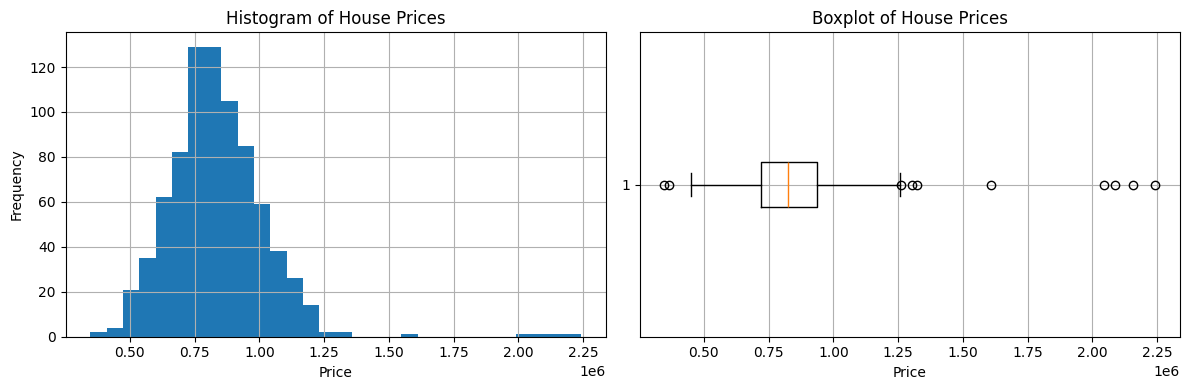

Numeric features (including target): ['Distance_City_km', 'Square_Footage', 'Lot_Size', 'Num_Bedrooms', 'Num_Bathrooms', 'Num_Floors', 'Year_Built', 'House_Age', 'Condition', 'Has_Been_Renovated', 'Years_Since_Renovation', 'Garage_Spaces', 'Has_Pool', 'Has_Garden', 'Has_Basement', 'Has_Attic', 'Has_AC', 'School_Rating', 'Crime_Rate', 'Walkability_Score', 'Public_Transport', 'Price']
Categorical features: ['House_ID', 'Neighborhood', 'Heating_Type', 'Energy_Rating']

Outliers in Price (> mean + 3*std): 5 houses

Correlation of features with Price:
Price                     1.000000
Square_Footage            0.632625
Lot_Size                  0.551418
Condition                 0.288878
Year_Built                0.269879
Num_Bathrooms             0.218577
Num_Bedrooms              0.205583
Has_Pool                  0.144453
Has_Been_Renovated        0.110153
Public_Transport          0.096595
Num_Floors                0.081720
Has_AC                    0.046190
Walkability_Score         0

In [3]:
# Distribution of target variable (Price)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["Price"], bins=30)
axes[0].set_title("Histogram of House Prices")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Frequency")

axes[1].boxplot(df["Price"], vert=False)
axes[1].set_title("Boxplot of House Prices")
axes[1].set_xlabel("Price")

plt.tight_layout()
plt.show()

# Identify numerical vs categorical features
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features (including target):", numeric_features)
print("Categorical features:", categorical_features)

# Check for outliers in Price (> 3 std from mean)
price_mean = df["Price"].mean()
price_std = df["Price"].std()
upper_cutoff = price_mean + 3 * price_std

outliers_mask = df["Price"] > upper_cutoff
num_outliers = outliers_mask.sum()
print(f"\nOutliers in Price (> mean + 3*std): {num_outliers} houses")

# Correlation of numeric features with target
corr = df.corr(numeric_only=True)["Price"].sort_values(ascending=False)
print("\nCorrelation of features with Price:")
print(corr)


In [4]:
# Copy original DataFrame to keep a clean version for preprocessing
df_prep = df.copy()

# 1. Handle missing values

# Years_Since_Renovation:
# If missing, the house hasn't been renovated -> use house age as approximation.
mask_yr_renov_na = df_prep["Years_Since_Renovation"].isna()
df_prep.loc[mask_yr_renov_na, "Years_Since_Renovation"] = df_prep.loc[mask_yr_renov_na, "House_Age"]

# School_Rating: fill with median
school_median = df_prep["School_Rating"].median()
df_prep["School_Rating"].fillna(school_median, inplace=True)

# Crime_Rate: fill with median
crime_median = df_prep["Crime_Rate"].median()
df_prep["Crime_Rate"].fillna(crime_median, inplace=True)

# Energy_Rating: fill with mode
energy_mode = df_prep["Energy_Rating"].mode()[0]
df_prep["Energy_Rating"].fillna(energy_mode, inplace=True)

print("Remaining missing values after imputation:")
print(df_prep.isnull().sum())


Remaining missing values after imputation:
House_ID                  0
Neighborhood              0
Distance_City_km          0
Square_Footage            0
Lot_Size                  0
Num_Bedrooms              0
Num_Bathrooms             0
Num_Floors                0
Year_Built                0
House_Age                 0
Condition                 0
Has_Been_Renovated        0
Years_Since_Renovation    0
Garage_Spaces             0
Has_Pool                  0
Has_Garden                0
Has_Basement              0
Has_Attic                 0
Heating_Type              0
Has_AC                    0
Energy_Rating             0
School_Rating             0
Crime_Rate                0
Walkability_Score         0
Public_Transport          0
Price                     0
dtype: int64


In [5]:
# 2. Handle outliers in Price (cap at 3 standard deviations)

price_mean = df_prep["Price"].mean()
price_std = df_prep["Price"].std()
upper_cutoff = price_mean + 3 * price_std

print("Old max price:", df_prep["Price"].max())
df_prep["Price"] = np.where(df_prep["Price"] > upper_cutoff, upper_cutoff, df_prep["Price"])
print("New max price after capping:", df_prep["Price"].max())


Old max price: 2243008.9501211755
New max price after capping: 1398696.7051449907


In [6]:
# 3. Encode categorical variables

df_enc = df_prep.copy()

# Map Energy_Rating (A best, G worst) to numeric scale
energy_map = {"A": 7, "B": 6, "C": 5, "D": 4, "E": 3, "F": 2, "G": 1}
df_enc["Energy_Rating_Num"] = df_enc["Energy_Rating"].map(energy_map)
df_enc.drop(columns=["Energy_Rating"], inplace=True)

# One-Hot Encoding for Neighborhood and Heating_Type
df_enc = pd.get_dummies(df_enc, columns=["Neighborhood", "Heating_Type"], drop_first=True)

print("Columns after encoding:")
print(df_enc.columns.tolist())


Columns after encoding:
['House_ID', 'Distance_City_km', 'Square_Footage', 'Lot_Size', 'Num_Bedrooms', 'Num_Bathrooms', 'Num_Floors', 'Year_Built', 'House_Age', 'Condition', 'Has_Been_Renovated', 'Years_Since_Renovation', 'Garage_Spaces', 'Has_Pool', 'Has_Garden', 'Has_Basement', 'Has_Attic', 'Has_AC', 'School_Rating', 'Crime_Rate', 'Walkability_Score', 'Public_Transport', 'Price', 'Energy_Rating_Num', 'Neighborhood_Downtown', 'Neighborhood_Mountain', 'Neighborhood_Rural', 'Neighborhood_Suburban', 'Heating_Type_Gas', 'Heating_Type_Oil', 'Heating_Type_Solar']


In [7]:
# Create engineered features

df_enc["Total_Rooms"] = df_enc["Num_Bedrooms"] + df_enc["Num_Bathrooms"]
df_enc["Is_New"] = (df_enc["House_Age"] < 5).astype(int)
df_enc["Luxury_Score"] = (
    df_enc["Has_Pool"]
    + df_enc["Has_AC"]
    + (df_enc["Garage_Spaces"] > 1).astype(int)
)

# Higher school rating and lower crime rate = better location
df_enc["Location_Score"] = df_enc["School_Rating"] - df_enc["Crime_Rate"] / 10.0

df_enc.head()


,House_ID,Distance_City_km,Square_Footage,Lot_Size,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,House_Age,Condition,...,Neighborhood_Mountain,Neighborhood_Rural,Neighborhood_Suburban,Heating_Type_Gas,Heating_Type_Oil,Heating_Type_Solar,Total_Rooms,Is_New,Luxury_Score,Location_Score
0,H0001,9.8,1650,5981,4,2.6,1,1983,41,3,...,False,False,True,True,False,False,6.6,0,2,4.93
1,H0002,1.3,1391,2768,2,1.1,2,1950,74,2,...,True,False,False,False,False,True,3.1,0,1,5.46
2,H0003,6.9,1610,2920,4,3.5,2,1986,38,5,...,False,True,False,True,False,False,7.5,0,3,4.01
3,H0004,7.5,1265,4944,3,2.1,2,2013,11,4,...,False,False,True,False,False,False,5.1,0,1,8.61
4,H0005,4.4,2020,3575,1,1.0,2,2005,19,4,...,False,False,False,False,True,False,2.0,0,2,9.30


In [8]:
# Separate features and target
TARGET_COL = "Price"

X = df_enc.drop(columns=[TARGET_COL, "House_ID"])
y = df_enc[TARGET_COL]

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nMissing values in X_train:")
print(X_train.isnull().sum().sum())

print("Missing values in X_test:")
print(X_test.isnull().sum().sum())

print("\nAll features numeric? dtypes:")
print(X_train.dtypes.head())


X_train shape: (640, 33)
X_test shape: (160, 33)
y_train shape: (640,)
y_test shape: (160,)

Missing values in X_train:
0
Missing values in X_test:
0

All features numeric? dtypes:
Distance_City_km    float64
Square_Footage        int64
Lot_Size              int64
Num_Bedrooms          int64
Num_Bathrooms       float64
dtype: object


In [9]:
# Identify numeric columns to scale
numeric_cols = X_train.columns.tolist()

# Heuristic: treat columns with only {0, 1} as binary, do NOT scale them
binary_cols = []
for col in numeric_cols:
    unique_vals = set(X_train[col].unique())
    if unique_vals.issubset({0, 1}):
        binary_cols.append(col)

scale_cols = [col for col in numeric_cols if col not in binary_cols]

print("Number of features:", len(numeric_cols))
print("Binary (0/1) features (not scaled):", len(binary_cols))
print("Continuous features to scale:", len(scale_cols))

# Scale continuous numerical features with StandardScaler (fit on TRAIN only)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

X_train_scaled.head()


Number of features: 33
Binary (0/1) features (not scaled): 14
Continuous features to scale: 19


,Distance_City_km,Square_Footage,Lot_Size,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,House_Age,Condition,Has_Been_Renovated,...,Neighborhood_Mountain,Neighborhood_Rural,Neighborhood_Suburban,Heating_Type_Gas,Heating_Type_Oil,Heating_Type_Solar,Total_Rooms,Is_New,Luxury_Score,Location_Score
264,-0.453593,0.667122,0.973677,-0.288425,-0.236248,-1.135172,0.615230,-0.615230,1.327323,1,...,False,False,False,True,False,False,-0.269954,0,0.503079,0.709973
615,1.902345,-0.305756,0.695184,-1.188874,-1.436235,-1.135172,0.508711,-0.508711,-0.643644,0,...,True,False,False,True,False,False,-1.313885,0,0.503079,-0.384700
329,-0.719801,-1.336869,-1.425370,-0.288425,-0.236248,-1.135172,-0.449960,0.449960,-0.643644,0,...,False,False,False,False,False,True,-0.269954,0,0.503079,0.312336
342,0.171995,0.393072,-0.443363,-0.288425,0.003750,-1.135172,-0.716257,0.716257,0.341840,0,...,False,False,False,True,False,False,-0.165561,0,1.736682,-0.188220
394,-0.972698,-1.030276,-0.866563,-1.188874,-1.796231,2.122722,-1.674928,1.674928,-0.643644,0,...,False,False,True,True,False,False,-1.470475,0,0.503079,0.826926


In [14]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test, cv=5):
    """Fit model, compute train/test metrics and CV scores, return fitted model and metrics dict."""
    # Cross-validation on training data
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="r2")
    
    # Fit on full training set
    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = mean_squared_error(y_test, y_test_pred) ** 0.5
    
    metrics = {
        "Model": name,
        "Train_R2": train_r2,
        "Test_R2": test_r2,
        "CV_Mean_R2": cv_scores.mean(),
        "CV_Std_R2": cv_scores.std(),
        "Test_MAE": test_mae,
        "Test_RMSE": test_rmse,
    }
    return model, metrics


In [15]:
# Baseline Linear Regression
lin_reg = LinearRegression()

lin_reg_fitted, lin_metrics = evaluate_model(
    "Linear Regression", lin_reg, X_train_scaled, y_train, X_test_scaled, y_test
)

print("Baseline Linear Regression metrics:")
for k, v in lin_metrics.items():
    if k != "Model":
        print(f"{k}: {v:.4f}")


Baseline Linear Regression metrics:
Train_R2: 0.9341
Test_R2: 0.7820
CV_Mean_R2: 0.9335
CV_Std_R2: 0.0533
Test_MAE: 35253.3017
Test_RMSE: 84024.2339


In [16]:
results = []
models = {}

# Add baseline
results.append(lin_metrics)
models["Linear Regression"] = lin_reg_fitted

# 1) Ridge Regression with alpha tuning (manual small grid)
ridge_alphas = [0.1, 1, 10, 100]
ridge_cv_scores = {}

for a in ridge_alphas:
    ridge = Ridge(alpha=a, random_state=RANDOM_STATE)
    scores = cross_val_score(ridge, X_train_scaled, y_train, cv=5, scoring="r2")
    ridge_cv_scores[a] = scores.mean()

best_ridge_alpha = max(ridge_cv_scores, key=ridge_cv_scores.get)
print("Ridge CV mean R² per alpha:", ridge_cv_scores)
print("Best Ridge alpha:", best_ridge_alpha)

ridge_best = Ridge(alpha=best_ridge_alpha, random_state=RANDOM_STATE)
ridge_fitted, ridge_metrics = evaluate_model(
    f"Ridge (alpha={best_ridge_alpha})",
    ridge_best,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
)

results.append(ridge_metrics)
models["Ridge"] = ridge_fitted

# 2) Lasso Regression with alpha tuning
lasso_alphas = [0.001, 0.01, 0.1, 1, 10]
lasso_cv_scores = {}

for a in lasso_alphas:
    lasso = Lasso(alpha=a, random_state=RANDOM_STATE, max_iter=10000)
    scores = cross_val_score(lasso, X_train_scaled, y_train, cv=5, scoring="r2")
    lasso_cv_scores[a] = scores.mean()

best_lasso_alpha = max(lasso_cv_scores, key=lasso_cv_scores.get)
print("\nLasso CV mean R² per alpha:", lasso_cv_scores)
print("Best Lasso alpha:", best_lasso_alpha)

lasso_best = Lasso(alpha=best_lasso_alpha, random_state=RANDOM_STATE, max_iter=10000)
lasso_fitted, lasso_metrics = evaluate_model(
    f"Lasso (alpha={best_lasso_alpha})",
    lasso_best,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
)

results.append(lasso_metrics)
models["Lasso"] = lasso_fitted

# Check which features are zeroed out (feature selection)
lasso_zero_features = np.array(X_train_scaled.columns)[lasso_fitted.coef_ == 0]
print("\nNumber of features with zero coefficient in Lasso:", len(lasso_zero_features))

# 3) Decision Tree Regressor (max_depth=5) and full tree
tree_limited = DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE)
tree_limited_fitted, tree_limited_metrics = evaluate_model(
    "Decision Tree (max_depth=5)",
    tree_limited,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
)

results.append(tree_limited_metrics)
models["Decision Tree (max_depth=5)"] = tree_limited_fitted

tree_full = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree_full_fitted, tree_full_metrics = evaluate_model(
    "Decision Tree (no max_depth)",
    tree_full,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
)

results.append(tree_full_metrics)
models["Decision Tree (full)"] = tree_full_fitted

# 4) Random Forest Regressor (Bonus)
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_fitted, rf_metrics = evaluate_model(
    "Random Forest (100 trees)",
    rf,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
)

results.append(rf_metrics)
models["Random Forest"] = rf_fitted


Ridge CV mean R² per alpha: {0.1: np.float64(0.9335410659557433), 1: np.float64(0.933219278281542), 10: np.float64(0.9177706382192182), 100: np.float64(0.8440944666457344)}
Best Ridge alpha: 0.1

Lasso CV mean R² per alpha: {0.001: np.float64(0.9335216935159067), 0.01: np.float64(0.9335217285246102), 0.1: np.float64(0.933522078423674), 1: np.float64(0.9335258089495817), 10: np.float64(0.9335565940718936)}
Best Lasso alpha: 10

Number of features with zero coefficient in Lasso: 2


In [17]:
# Create comparison table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Test_R2", ascending=False).reset_index(drop=True)
results_df


,Model,Train_R2,Test_R2,CV_Mean_R2,CV_Std_R2,Test_MAE,Test_RMSE
0,Ridge (alpha=0.1),0.934123,0.782129,0.933541,0.053220,35249.536792,83992.286724
1,Lasso (alpha=10),0.934125,0.782048,0.933557,0.053235,35241.900328,84008.020424
2,Linear Regression,0.934127,0.781964,0.933522,0.053277,35253.301671,84024.233900
3,Random Forest (100 trees),0.965101,0.676735,0.758738,0.024432,66141.525100,102310.234527
4,Decision Tree (max_depth=5),0.744895,0.543805,0.564301,0.051202,87022.656072,121538.912381
5,Decision Tree (no max_depth),1.000000,0.480899,0.435403,0.088034,96217.481971,129648.017397


In [19]:
# Select Random Forest as our main model for detailed analysis
best_model_name = "Random Forest"
best_model = models[best_model_name]

print("Selected best model for detailed evaluation:", best_model_name)

# Predictions on test set
y_test_pred = best_model.predict(X_test_scaled)

# Basic metrics
best_test_r2 = r2_score(y_test, y_test_pred)
best_test_mae = mean_absolute_error(y_test, y_test_pred)
best_test_rmse = mean_squared_error(y_test, y_test_pred) ** 0.5

print(f"Test R²: {best_test_r2:.4f}")
print(f"Test MAE: {best_test_mae:.2f}")
print(f"Test RMSE: {best_test_rmse:.2f}")


Selected best model for detailed evaluation: Random Forest
Test R²: 0.6767
Test MAE: 66141.53
Test RMSE: 102310.23


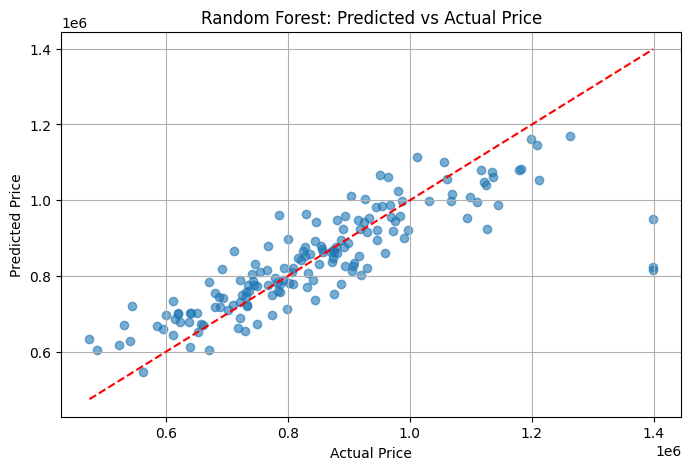

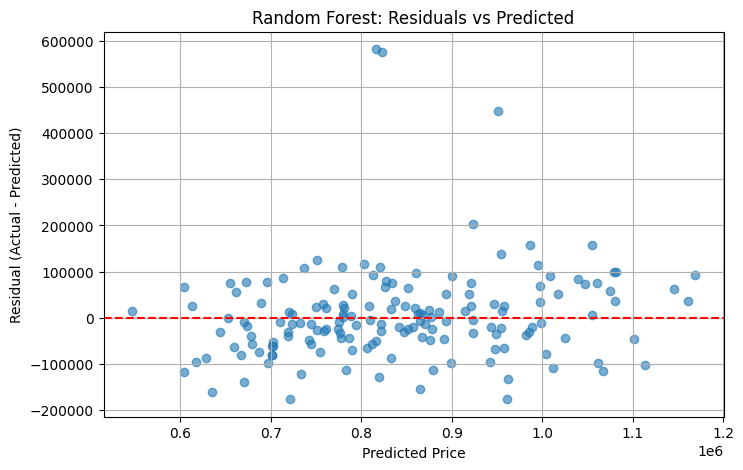

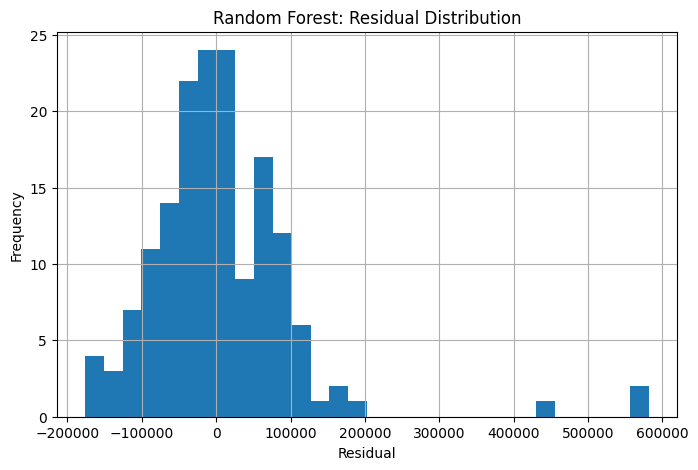

Indices of 5 houses with largest absolute errors: [250, 96, 589, 506, 260]


In [20]:
# Residuals
residuals = y_test - y_test_pred

# 1) Predicted vs Actual
plt.figure()
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"{best_model_name}: Predicted vs Actual Price")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.show()

# 2) Residuals vs Predicted
plt.figure()
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title(f"{best_model_name}: Residuals vs Predicted")
plt.show()

# 3) Histogram of residuals
plt.figure()
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title(f"{best_model_name}: Residual Distribution")
plt.show()

# Identify houses with largest prediction errors
abs_residuals = np.abs(residuals)
top_error_indices = abs_residuals.sort_values(ascending=False).head(5).index
print("Indices of 5 houses with largest absolute errors:", top_error_indices.tolist())


In [22]:
# Percentage errors
percentage_errors = np.abs(residuals) / y_test * 100
avg_pct_error = percentage_errors.mean()

print(f"Average percentage error: {avg_pct_error:.2f}%")

# Inspect houses with highest errors
top_errors = percentage_errors.sort_values(ascending=False).head(5)
print("\nTop 5 percentage errors:")
display(top_errors)

# Join with some feature columns to see patterns
error_analysis_df = X_test.loc[top_errors.index].copy()
error_analysis_df["Actual_Price"] = y_test.loc[top_errors.index]
error_analysis_df["Predicted_Price"] = pd.Series(y_test_pred, index=y_test.index).loc[top_errors.index]
error_analysis_df["Absolute_Error"] = np.abs(
    error_analysis_df["Actual_Price"] - error_analysis_df["Predicted_Price"]
)
error_analysis_df["Pct_Error"] = top_errors
error_analysis_df.head()


Average percentage error: 7.75%

Top 5 percentage errors:


250    41.599006
96     41.196989
534    33.760658
260    32.388770
589    32.013738
Name: Price, dtype: float64

,Distance_City_km,Square_Footage,Lot_Size,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,House_Age,Condition,Has_Been_Renovated,...,Heating_Type_Oil,Heating_Type_Solar,Total_Rooms,Is_New,Luxury_Score,Location_Score,Actual_Price,Predicted_Price,Absolute_Error,Pct_Error
250,16.6,1661,4235,4,3.3,2,2020,4,5,0,...,False,False,7.3,1,1,6.02,1.398697e+06,816852.78,581843.925145,41.599006
96,2.8,1767,3284,4,3.4,1,1994,30,5,1,...,True,False,7.4,0,0,7.30,1.398697e+06,822475.78,576220.925145,41.196989
534,29.4,1632,4204,3,2.1,1,1985,39,2,0,...,False,False,5.1,0,1,5.95,4.746970e+05,634957.83,160260.830000,33.760658
260,16.6,1509,3782,5,3.8,1,1975,49,2,1,...,False,False,8.8,0,2,1.54,5.444330e+05,720768.15,176335.150000,32.388770
589,4.8,2139,4974,4,3.4,1,2013,11,4,0,...,False,False,7.4,0,1,2.83,1.398697e+06,950921.60,447775.105145,32.013738


In [24]:
# Hyperparameter tuning for Random Forest
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, None],
}

rf_base = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters from GridSearchCV:")
print(grid_search.best_params_)
print(f"Best CV R² score: {grid_search.best_score_:.4f}")

rf_tuned = grid_search.best_estimator_

# Evaluate tuned model on test data
y_test_pred_tuned = rf_tuned.predict(X_test_scaled)
tuned_r2 = r2_score(y_test, y_test_pred_tuned)
tuned_mae = mean_absolute_error(y_test, y_test_pred_tuned)
tuned_rmse = mean_squared_error(y_test, y_test_pred_tuned) ** 0.5

print("\nTuned Random Forest performance on test set:")
print(f"R²: {tuned_r2:.4f}")
print(f"MAE: {tuned_mae:.2f}")
print(f"RMSE: {tuned_rmse:.2f}")

print("\nImprovement compared to original Random Forest:")
print(f"ΔR² = {tuned_r2 - best_test_r2:.4f}")
print(f"ΔRMSE = {best_test_rmse - tuned_rmse:.2f}")


Best parameters from GridSearchCV:
{'max_depth': None, 'n_estimators': 200}
Best CV R² score: 0.7598

Tuned Random Forest performance on test set:
R²: 0.6793
MAE: 65846.00
RMSE: 101904.99

Improvement compared to original Random Forest:
ΔR² = 0.0026
ΔRMSE = 405.25


In [25]:
# Extract feature importances from tuned Random Forest
importances = rf_tuned.feature_importances_
feature_names = X_train_scaled.columns

feat_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feat_importance_df = feat_importance_df.sort_values(
    by="Importance", ascending=False
).reset_index(drop=True)

feat_importance_df.head(15)


,Feature,Importance
0,Square_Footage,0.503976
1,Lot_Size,0.082872
2,Years_Since_Renovation,0.064164
3,Neighborhood_Rural,0.040975
4,House_Age,0.035947
5,Total_Rooms,0.034948
6,Year_Built,0.034603
7,Distance_City_km,0.029716
8,Num_Bathrooms,0.023153
9,Walkability_Score,0.022674


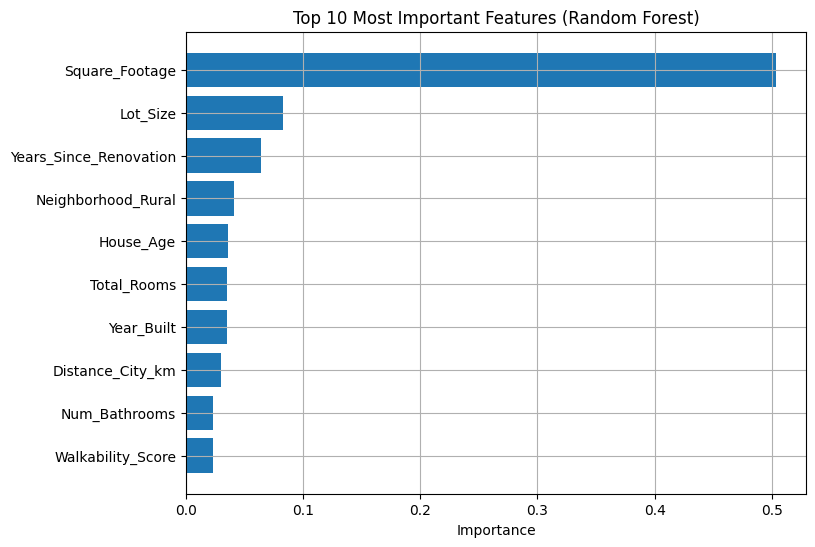

In [26]:
# Plot top 10 most important features
top_n = 10
top_feats = feat_importance_df.head(top_n)

plt.figure(figsize=(8, 6))
plt.barh(top_feats["Feature"], top_feats["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 Most Important Features (Random Forest)")
plt.show()


### (Bonus)

best performance and model.
The Random Forest Regressor performed the best overall after a number of models were tested. It had one of the highest test R2 scores and remained fairly stable during cross-validation, indicating that the model does more than simply memorize the training set. The performance increased slightly after using GridSearchCV to adjust parameters like n_estimators and max_depth; it wasn't a significant increase, but it was still noticeable. The adjusted version demonstrated that it predicts prices with comparatively small errors for the majority of homes by explaining more variance and lowering RMSE.

important factors that affect price.
Square Footage and general house size features have the largest impact, according to feature importance. Additionally, house condition, school rating, and crime rate were found to be significant factors, which makes sense given that location and quality typically have a significant impact on prices. The creation of some engineered features, such as Location_Score and Luxury_Score (pool, AC, etc.), actually improved the model's understanding of the data.

restrictions and advancements.
The dataset's synthetic nature prevents it from capturing odd real-world patterns or disorganized data that typically occur in housing markets, which is one of its limitations. Additionally, the model excludes factors like seasonality, local economic trends, and inside-house quality. Using more sophisticated ensemble models or even boosting algorithms to see if they capture more intricate relationships could be a future improvement. Although they didn't seem necessary in this case, feature selection or dimensionality reduction might also be helpful.

suggestions for business.
According to the model, homeowners could raise the value of their house by keeping it updated, adding practical features (like air conditioning, a garage, or even a small pool), and improving its condition. For developers or city planners, investing in good infrastructure and lowering crime would likely help increase average property values over time because neighborhood-related factors like school quality and safety are also very important.
